#####  Zonal Averaging using UXarray
- Open grid & data file
- Zonal Averaging
- Using layout to combine plots
 
Ming Ge May 2025

In [1]:
import numpy as np
import uxarray as ux

from holoviews import opts
import holoviews as hv
# Tell HoloViews (and hvplot) to use the Matplotlib backend for rendering plots
hv.extension( "matplotlib")

#### Read grid and data using uxarray

:Image   [x,y]   (x_y surface_pressure)
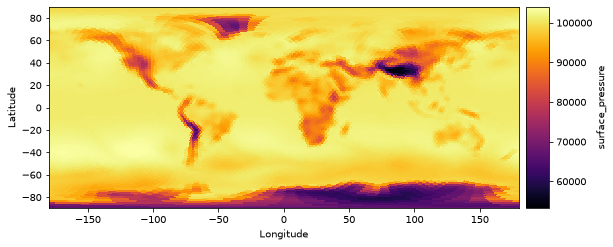

In [2]:
dir_data = '/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/240km_uniform/'

flnm_grid = dir_data + 'x1.10242.static.nc' 
flnm_data = dir_data + 'history.2014-09-11_00.00.00.nc'
 
uxds = ux.open_dataset(flnm_grid, flnm_data)
uxds["surface_pressure"][0,:].plot(cmap="inferno", periodic_elements="split")

#### Zonal Averaging
The range of latitudes can be modified by using the lat parameter. It accepts:
- Single scalar: e.g., lat=45
- List/array: e.g., lat=[10, 20] or lat=np.array([10, 20])
- Tuple: e.g., (min_lat, max_lat, step)

:Overlay
   .Curve.I   :Curve   [latitudes]   (surface_pressure_zonal_mean)
   .Scatter.I :Scatter   [latitudes]   (surface_pressure_zonal_mean)
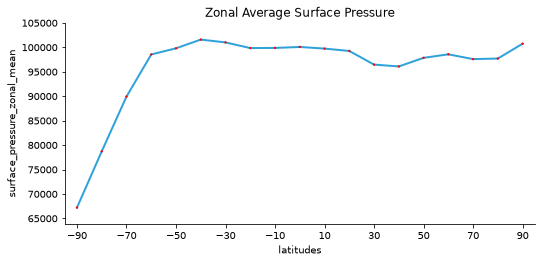

In [5]:
import warnings
warnings.filterwarnings('ignore')
# Use hvplot to generate HoloViews objects
zonal_mean_psfc = uxds["surface_pressure"][0].zonal_mean(lat=(-90, 90, 10))

line_plot = zonal_mean_psfc.hvplot.line()
scatter_plot = zonal_mean_psfc.hvplot.scatter(color="red")

# The overlay syntax (*) will now work
(line_plot * scatter_plot).opts(
    title="Zonal Average Surface Pressure",
    xticks=list(np.arange(-90, 100, 20)),
    xlim=(-95, 95)
)